In [1]:
import json
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../..')
from style_setup import set_thesis_style
set_thesis_style()


# Llama small

## Load data

In [11]:
data_paths_8b = {
    "Single source": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_single_source.jsonl",
    "Multi source": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_multi_source.jsonl",
    "Human source": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_human_source.jsonl",
    "Vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_vanilla.jsonl"
}

scores_8b = {}

for source, path in data_paths_8b.items():
    with open(path, 'r') as f:
        data = [line for line in f]
    
    scores_8b[source] = []
    for i, line in enumerate(data):
        scores_8b[source].append(json.loads(line))




## Extract weighted scores

In [12]:
single_source_scores_8b = {}
for i, line in enumerate(scores_8b["Single source"]):
    model_name = line["model_name"]
    if model_name not in single_source_scores_8b:
        single_source_scores_8b[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    single_source_scores_8b[model_name].append(weighted_score)

multi_source_scores_8b = {}
for i, line in enumerate(scores_8b["Multi source"]):
    model_name = line["model_name"]
    if model_name not in multi_source_scores_8b:
        multi_source_scores_8b[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    multi_source_scores_8b[model_name].append(weighted_score)

human_source_scores_8b = {}
for i, line in enumerate(scores_8b["Human source"]):
    model_name = line["model_name"]
    if model_name not in human_source_scores_8b:
        human_source_scores_8b[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    human_source_scores_8b[model_name].append(weighted_score)

vanilla_scores_8b = {}
for i, line in enumerate(scores_8b["Vanilla"]):
    model_name = line["model_name"]
    if model_name not in vanilla_scores_8b:
        vanilla_scores_8b[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    vanilla_scores_8b[model_name].append(weighted_score)


### Normalize by sum of token probabilities

In [41]:
single_source_scores_8b = {}
for i, line in enumerate(scores_8b["Single source"]):
    model_name = line["model_name"]
    if model_name not in single_source_scores_8b:
        single_source_scores_8b[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    # Normalize the score by the sum of the probabilities
    weighted_normalized_score = weighted_score / sum(probabilities)

    single_source_scores_8b[model_name].append(weighted_normalized_score)

multi_source_scores_8b = {}
for i, line in enumerate(scores_8b["Multi source"]):
    model_name = line["model_name"]
    if model_name not in multi_source_scores_8b:
        multi_source_scores_8b[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    multi_source_scores_8b[model_name].append(weighted_normalized_score)

human_source_scores_8b = {}
for i, line in enumerate(scores_8b["Human source"]):
    model_name = line["model_name"]
    if model_name not in human_source_scores_8b:
        human_source_scores_8b[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    human_source_scores_8b[model_name].append(weighted_normalized_score)

vanilla_scores_8b = {}
for i, line in enumerate(scores_8b["Vanilla"]):
    model_name = line["model_name"]
    if model_name not in vanilla_scores_8b:
        vanilla_scores_8b[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    vanilla_scores_8b[model_name].append(weighted_normalized_score)


## Save average scores

In [42]:
# Create a dictionary with the mean scores for each model and source
data_8b = {
    'llama': [
        np.mean(single_source_scores_8b['llama']),
        np.mean(multi_source_scores_8b['llama']),
        np.mean(human_source_scores_8b['llama']),
        np.mean(vanilla_scores_8b['llama'])
    ],
    'qwen': [
        np.mean(single_source_scores_8b['qwen']),
        np.mean(multi_source_scores_8b['qwen']),
        np.mean(human_source_scores_8b['qwen']),
        np.mean(vanilla_scores_8b['qwen'])
    ],
    'falcon': [
        np.mean(single_source_scores_8b['falcon']),
        np.mean(multi_source_scores_8b['falcon']),
        np.mean(human_source_scores_8b['falcon']),
        np.mean(vanilla_scores_8b['falcon'])
    ],
    'gemma': [
        np.mean(single_source_scores_8b['gemma']),
        np.mean(multi_source_scores_8b['gemma']),
        np.mean(human_source_scores_8b['gemma']),
        np.mean(vanilla_scores_8b['gemma'])
    ],
    'human': [
        np.mean(single_source_scores_8b['human']),
        np.mean(multi_source_scores_8b['human']),
        np.mean(human_source_scores_8b['human']),
        np.mean(vanilla_scores_8b['human'])
    ]
}

# Create DataFrame with specified index
df_8b = pd.DataFrame(data_8b, index=['Single source', 'Multi source', 'Human source', 'Vanilla'])
df_8b.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/small/llama_8b_mean_scores.csv')
df_8b.head(10)




,llama,qwen,falcon,gemma,human
Single source,4.044105,3.971403,3.923135,3.921624,3.318840
Multi source,4.390315,4.317917,4.264835,4.277153,3.786430
Human source,4.111813,4.106027,4.052482,4.079050,3.650149
Vanilla,3.979249,3.901087,3.863736,3.826862,3.321119


## Plot

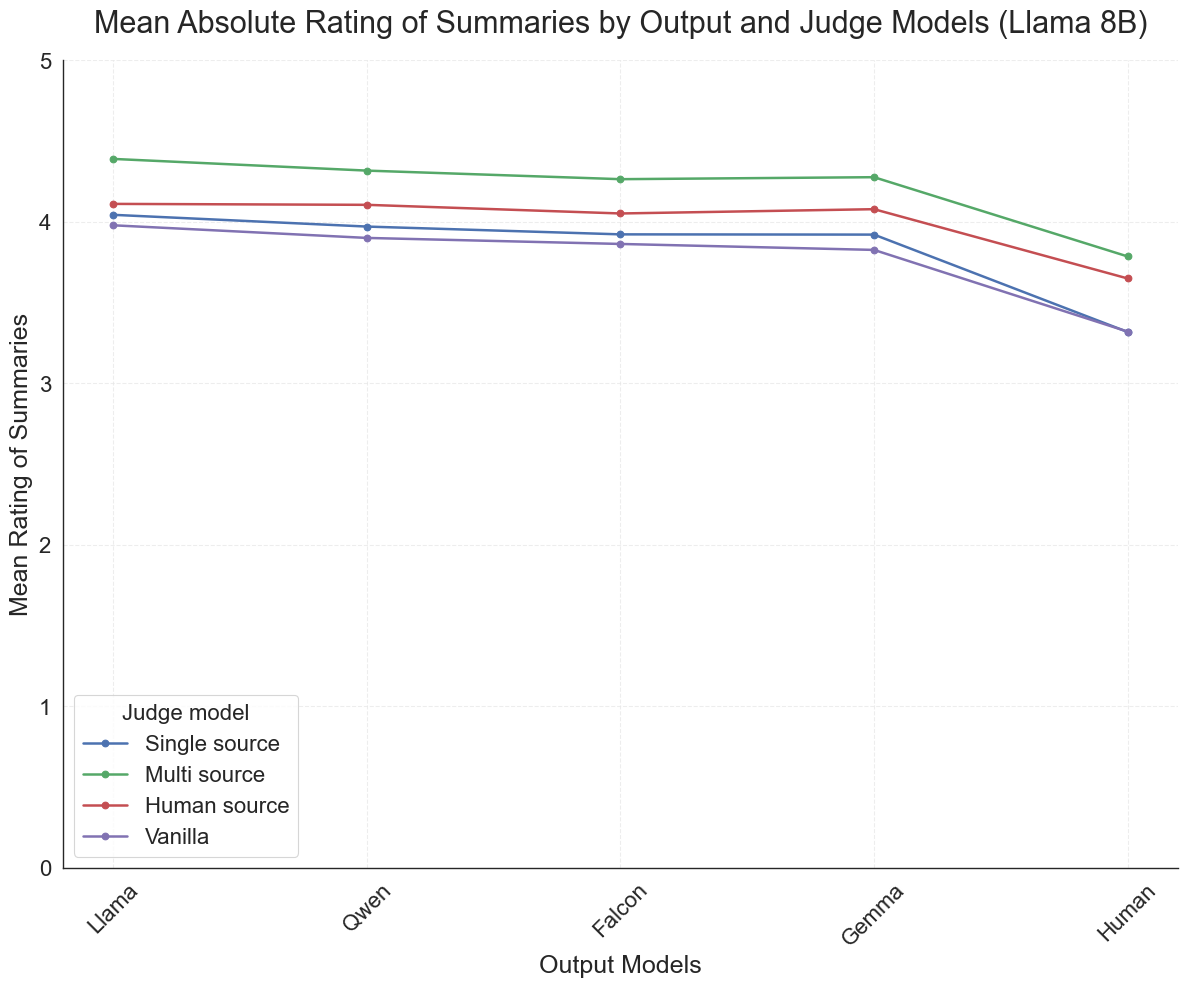

In [44]:
plt.figure(figsize=(12, 10))
for idx, row in df_8b.iterrows():
    plt.plot(df_8b.columns, row.values, marker='o', label=idx)

plt.xlabel('Output Models', fontsize=18)
plt.ylabel('Mean Rating of Summaries', fontsize=18)
plt.title('Mean Absolute Rating of Summaries by Output and Judge Models (Llama 8B)', fontsize=22, pad=20)
plt.legend(fontsize=16, title="Judge model", title_fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=range(len(df_8b.columns)), labels=[col.capitalize() for col in df_8b.columns], rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/llama_8b/line_abs_small.png')
plt.show()


## Significance testing

In [16]:
llama_scores_8b = {}
qwen_scores_8b = {}
falcon_scores_8b = {}
gemma_scores_8b = {}
human_scores_8b = {}

for name, variable in [("single_source", single_source_scores_8b), ("multi_source", multi_source_scores_8b), ("human_source", human_source_scores_8b), ("vanilla", vanilla_scores_8b)]:
    llama_scores_8b[name] = [score for score in variable["llama"]]
    qwen_scores_8b[name] = [score for score in variable["qwen"]]
    falcon_scores_8b[name] = [score for score in variable["falcon"]]
    gemma_scores_8b[name] = [score for score in variable["gemma"]]
    human_scores_8b[name] = [score for score in variable["human"]]
    

In [17]:
score_dict_8b = {
    "llama_scores": llama_scores_8b,
    "qwen_scores": qwen_scores_8b,
    "falcon_scores": falcon_scores_8b,
    "gemma_scores": gemma_scores_8b,
    "human_scores": human_scores_8b,
}




for name, score_data in score_dict_8b.items():
    print("----------------------------------------------------")
    print(f"{name}:")
    # Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
    groups = [scores for condition, scores in score_data.items()] 
    H, p_value = stats.kruskal(*groups)

    dataset_names = [condition for condition, scores in score_data.items()] 

    print(f"Kruskal-Wallis H-test results:")
    print(f"H-statistic: {H:.2f}")
    print(f"p-value: {p_value:.2e}")

    # If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
    if p_value < 0.05:
        print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
        n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
        alpha = 0.05 / n_comparisons  # Bonferroni correction
        
        for i in range(len(dataset_names)):
            for j in range(i + 1, len(dataset_names)):
                stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
                print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
                print(f"U-statistic: {stat:.2f}")
                print(f"p-value: {p:.2e}")
                print(f"Significant difference: {'Yes' if p < alpha else 'No'}")



----------------------------------------------------
llama_scores:
Kruskal-Wallis H-test results:
H-statistic: 132.20
p-value: 1.81e-28

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

single_source vs multi_source:
U-statistic: 1250.00
p-value: 4.94e-20
Significant difference: Yes

single_source vs human_source:
U-statistic: 4061.00
p-value: 2.18e-02
Significant difference: No

single_source vs vanilla:
U-statistic: 5769.00
p-value: 6.04e-02
Significant difference: No

multi_source vs human_source:
U-statistic: 8539.50
p-value: 5.16e-18
Significant difference: Yes

multi_source vs vanilla:
U-statistic: 8795.50
p-value: 1.73e-20
Significant difference: Yes

human_source vs vanilla:
U-statistic: 6544.00
p-value: 1.62e-04
Significant difference: Yes
----------------------------------------------------
qwen_scores:
Kruskal-Wallis H-test results:
H-statistic: 138.94
p-value: 6.40e-30

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

single_sou

# Llama medium

## Load data

In [18]:
data_paths_70b = {
    "Single source small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_single_source_small.jsonl",
    "Single source medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_single_source_medium.jsonl",
    "Single source large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_single_source_large.jsonl",
    "Multi source small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_multi_source_small.jsonl",
    "Multi source medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_multi_source_medium.jsonl",
    "Multi source large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_multi_source_large.jsonl",
    "Human source": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_human_source.jsonl",
    "Vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_vanilla.jsonl"
}

scores_70b = {}

for source, path in data_paths_70b.items():
    with open(path, 'r') as f:
        data = [line for line in f]
    
    scores_70b[source] = []
    for i, line in enumerate(data):
        scores_70b[source].append(json.loads(line))





## Extract weighted scores

In [19]:
single_source_scores_70b_small = {}
for i, line in enumerate(scores_70b["Single source small"]):
    model_name = line["model_name"]
    if model_name not in single_source_scores_70b_small:
        single_source_scores_70b_small[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    single_source_scores_70b_small[model_name].append(weighted_score)

single_source_scores_70b_medium = {}
for i, line in enumerate(scores_70b["Single source medium"]):
    model_name = line["model_name"]
    if model_name not in single_source_scores_70b_medium:
        single_source_scores_70b_medium[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    single_source_scores_70b_medium[model_name].append(weighted_score)

single_source_scores_70b_large = {}
for i, line in enumerate(scores_70b["Single source large"]):
    model_name = line["model_name"]
    if model_name not in single_source_scores_70b_large:
        single_source_scores_70b_large[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    single_source_scores_70b_large[model_name].append(weighted_score)

multi_source_scores_70b_small = {}
for i, line in enumerate(scores_70b["Multi source small"]):
    model_name = line["model_name"]
    if model_name not in multi_source_scores_70b_small:
        multi_source_scores_70b_small[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    multi_source_scores_70b_small[model_name].append(weighted_score)

multi_source_scores_70b_medium = {}
for i, line in enumerate(scores_70b["Multi source medium"]):
    model_name = line["model_name"]
    if model_name not in multi_source_scores_70b_medium:
        multi_source_scores_70b_medium[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    multi_source_scores_70b_medium[model_name].append(weighted_score)

multi_source_scores_70b_large = {}
for i, line in enumerate(scores_70b["Multi source large"]):
    model_name = line["model_name"]
    if model_name not in multi_source_scores_70b_large:
        multi_source_scores_70b_large[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    multi_source_scores_70b_large[model_name].append(weighted_score)

human_source_scores_70b = {}
for i, line in enumerate(scores_70b["Human source"]):
    model_name = line["model_name"]
    if model_name not in human_source_scores_70b:
        human_source_scores_70b[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    human_source_scores_70b[model_name].append(weighted_score)

vanilla_scores_70b = {}
for i, line in enumerate(scores_70b["Vanilla"]):
    model_name = line["model_name"]
    if model_name not in vanilla_scores_70b:
        vanilla_scores_70b[model_name] = []

    weighted_score = 0
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob

    vanilla_scores_70b[model_name].append(weighted_score)


### Normalize by dividing through sum of token probabilities

In [45]:
single_source_scores_70b_small = {}
for i, line in enumerate(scores_70b["Single source small"]):
    model_name = line["model_name"]
    if model_name not in single_source_scores_70b_small:
        single_source_scores_70b_small[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    single_source_scores_70b_small[model_name].append(weighted_normalized_score)

single_source_scores_70b_medium = {}
for i, line in enumerate(scores_70b["Single source medium"]):
    model_name = line["model_name"]
    if model_name not in single_source_scores_70b_medium:
        single_source_scores_70b_medium[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    single_source_scores_70b_medium[model_name].append(weighted_normalized_score)

single_source_scores_70b_large = {}
for i, line in enumerate(scores_70b["Single source large"]):
    model_name = line["model_name"]
    if model_name not in single_source_scores_70b_large:
        single_source_scores_70b_large[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    single_source_scores_70b_large[model_name].append(weighted_normalized_score)

multi_source_scores_70b_small = {}
for i, line in enumerate(scores_70b["Multi source small"]):
    model_name = line["model_name"]
    if model_name not in multi_source_scores_70b_small:
        multi_source_scores_70b_small[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    multi_source_scores_70b_small[model_name].append(weighted_normalized_score)

multi_source_scores_70b_medium = {}
for i, line in enumerate(scores_70b["Multi source medium"]):
    model_name = line["model_name"]
    if model_name not in multi_source_scores_70b_medium:
        multi_source_scores_70b_medium[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    multi_source_scores_70b_medium[model_name].append(weighted_normalized_score)

multi_source_scores_70b_large = {}
for i, line in enumerate(scores_70b["Multi source large"]):
    model_name = line["model_name"]
    if model_name not in multi_source_scores_70b_large:
        multi_source_scores_70b_large[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    multi_source_scores_70b_large[model_name].append(weighted_normalized_score)

human_source_scores_70b = {}
for i, line in enumerate(scores_70b["Human source"]):
    model_name = line["model_name"]
    if model_name not in human_source_scores_70b:
        human_source_scores_70b[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    human_source_scores_70b[model_name].append(weighted_normalized_score)

vanilla_scores_70b = {}
for i, line in enumerate(scores_70b["Vanilla"]):
    model_name = line["model_name"]
    if model_name not in vanilla_scores_70b:
        vanilla_scores_70b[model_name] = []

    weighted_score = 0
    probabilities = []
    for rating, prob in line["token_probabilities"][0]["target_probs"].items():
        weighted_score += int(rating) * prob
        probabilities.append(prob)

    weighted_normalized_score = weighted_score / sum(probabilities)

    vanilla_scores_70b[model_name].append(weighted_normalized_score)


## Save scores to summary csv's

In [46]:
# Create a dictionary with the mean scores for each model and source
data_70b_small = {
    'llama': [
        np.mean(single_source_scores_70b_small['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(multi_source_scores_70b_small['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(human_source_scores_70b['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(vanilla_scores_70b['meta-llama/Meta-Llama-3.1-70B-Instruct'])
    ],
    'qwen': [
        np.mean(single_source_scores_70b_small['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(multi_source_scores_70b_small['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(human_source_scores_70b['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(vanilla_scores_70b['Qwen/Qwen2.5-72B-Instruct'])
    ],
    'mistral': [
        np.mean(single_source_scores_70b_small['mistral-large-latest']),
        np.mean(multi_source_scores_70b_small['mistral-large-latest']),
        np.mean(human_source_scores_70b['mistral-large-latest']),
        np.mean(vanilla_scores_70b['mistral-large-latest'])
    ],
    'command': [
        np.mean(single_source_scores_70b_small['command-r-plus']),
        np.mean(multi_source_scores_70b_small['command-r-plus']),
        np.mean(human_source_scores_70b['command-r-plus']),
        np.mean(vanilla_scores_70b['command-r-plus'])
    ],
    'human': [
        np.mean(single_source_scores_70b_small['human']),
        np.mean(multi_source_scores_70b_small['human']),
        np.mean(human_source_scores_70b['human']),
        np.mean(vanilla_scores_70b['human'])
    ]
}

data_70b_medium = {
    'llama': [
        np.mean(single_source_scores_70b_medium['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(multi_source_scores_70b_medium['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(human_source_scores_70b['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(vanilla_scores_70b['meta-llama/Meta-Llama-3.1-70B-Instruct'])
    ],
    'qwen': [
        np.mean(single_source_scores_70b_medium['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(multi_source_scores_70b_medium['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(human_source_scores_70b['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(vanilla_scores_70b['Qwen/Qwen2.5-72B-Instruct'])
    ],
    'mistral': [
        np.mean(single_source_scores_70b_medium['mistral-large-latest']),
        np.mean(multi_source_scores_70b_medium['mistral-large-latest']),
        np.mean(human_source_scores_70b['mistral-large-latest']),
        np.mean(vanilla_scores_70b['mistral-large-latest'])
    ],
    'command': [
        np.mean(single_source_scores_70b_medium['command-r-plus']),
        np.mean(multi_source_scores_70b_medium['command-r-plus']),
        np.mean(human_source_scores_70b['command-r-plus']),
        np.mean(vanilla_scores_70b['command-r-plus'])
    ],
    'human': [
        np.mean(single_source_scores_70b_medium['human']),
        np.mean(multi_source_scores_70b_medium['human']),
        np.mean(human_source_scores_70b['human']),
        np.mean(vanilla_scores_70b['human'])
    ]
}

data_70b_large = {
    'llama': [
        np.mean(single_source_scores_70b_large['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(multi_source_scores_70b_large['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(human_source_scores_70b['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(vanilla_scores_70b['meta-llama/Meta-Llama-3.1-70B-Instruct'])
    ],
    'qwen': [
        np.mean(single_source_scores_70b_large['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(multi_source_scores_70b_large['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(human_source_scores_70b['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(vanilla_scores_70b['Qwen/Qwen2.5-72B-Instruct'])
    ],
    'mistral': [
        np.mean(single_source_scores_70b_large['mistral-large-latest']),
        np.mean(multi_source_scores_70b_large['mistral-large-latest']),
        np.mean(human_source_scores_70b['mistral-large-latest']),
        np.mean(vanilla_scores_70b['mistral-large-latest'])
    ],
    'command': [
        np.mean(single_source_scores_70b_large['command-r-plus']),
        np.mean(multi_source_scores_70b_large['command-r-plus']),
        np.mean(human_source_scores_70b['command-r-plus']),
        np.mean(vanilla_scores_70b['command-r-plus'])
    ],
    'human': [
        np.mean(single_source_scores_70b_large['human']),
        np.mean(multi_source_scores_70b_large['human']),
        np.mean(human_source_scores_70b['human']),
        np.mean(vanilla_scores_70b['human'])
    ]
}

# Create averaged DataFrame
data_70b_averaged = {
    'llama': [
        np.mean([
            np.mean(single_source_scores_70b_small['meta-llama/Meta-Llama-3.1-70B-Instruct']),
            np.mean(single_source_scores_70b_medium['meta-llama/Meta-Llama-3.1-70B-Instruct']),
            np.mean(single_source_scores_70b_large['meta-llama/Meta-Llama-3.1-70B-Instruct'])
        ]),
        np.mean([
            np.mean(multi_source_scores_70b_small['meta-llama/Meta-Llama-3.1-70B-Instruct']),
            np.mean(multi_source_scores_70b_medium['meta-llama/Meta-Llama-3.1-70B-Instruct']),
            np.mean(multi_source_scores_70b_large['meta-llama/Meta-Llama-3.1-70B-Instruct'])
        ]),
        np.mean(human_source_scores_70b['meta-llama/Meta-Llama-3.1-70B-Instruct']),
        np.mean(vanilla_scores_70b['meta-llama/Meta-Llama-3.1-70B-Instruct'])
    ],
    'qwen': [
        np.mean([
            np.mean(single_source_scores_70b_small['Qwen/Qwen2.5-72B-Instruct']),
            np.mean(single_source_scores_70b_medium['Qwen/Qwen2.5-72B-Instruct']),
            np.mean(single_source_scores_70b_large['Qwen/Qwen2.5-72B-Instruct'])
        ]),
        np.mean([
            np.mean(multi_source_scores_70b_small['Qwen/Qwen2.5-72B-Instruct']),
            np.mean(multi_source_scores_70b_medium['Qwen/Qwen2.5-72B-Instruct']),
            np.mean(multi_source_scores_70b_large['Qwen/Qwen2.5-72B-Instruct'])
        ]),
        np.mean(human_source_scores_70b['Qwen/Qwen2.5-72B-Instruct']),
        np.mean(vanilla_scores_70b['Qwen/Qwen2.5-72B-Instruct'])
    ],
    'mistral': [
        np.mean([
            np.mean(single_source_scores_70b_small['mistral-large-latest']),
            np.mean(single_source_scores_70b_medium['mistral-large-latest']),
            np.mean(single_source_scores_70b_large['mistral-large-latest'])
        ]),
        np.mean([
            np.mean(multi_source_scores_70b_small['mistral-large-latest']),
            np.mean(multi_source_scores_70b_medium['mistral-large-latest']),
            np.mean(multi_source_scores_70b_large['mistral-large-latest'])
        ]),
        np.mean(human_source_scores_70b['mistral-large-latest']),
        np.mean(vanilla_scores_70b['mistral-large-latest'])
    ],
    'command': [
        np.mean([
            np.mean(single_source_scores_70b_small['command-r-plus']),
            np.mean(single_source_scores_70b_medium['command-r-plus']),
            np.mean(single_source_scores_70b_large['command-r-plus'])
        ]),
        np.mean([
            np.mean(multi_source_scores_70b_small['command-r-plus']),
            np.mean(multi_source_scores_70b_medium['command-r-plus']),
            np.mean(multi_source_scores_70b_large['command-r-plus'])
        ]),
        np.mean(human_source_scores_70b['command-r-plus']),
        np.mean(vanilla_scores_70b['command-r-plus'])
    ],
    'human': [
        np.mean([
            np.mean(single_source_scores_70b_small['human']),
            np.mean(single_source_scores_70b_medium['human']),
            np.mean(single_source_scores_70b_large['human'])
        ]),
        np.mean([
            np.mean(multi_source_scores_70b_small['human']),
            np.mean(multi_source_scores_70b_medium['human']),
            np.mean(multi_source_scores_70b_large['human'])
        ]),
        np.mean(human_source_scores_70b['human']),
        np.mean(vanilla_scores_70b['human'])
    ]
}



# Create DataFrame with specified index
df_70b_small = pd.DataFrame(data_70b_small, index=['Single source', 'Multi source', 'Human source', 'Vanilla'])
df_70b_small.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_mean_scores_small.csv')
display(df_70b_small)

df_70b_medium = pd.DataFrame(data_70b_medium, index=['Single source', 'Multi source', 'Human source', 'Vanilla'])
df_70b_medium.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_mean_scores_medium.csv')
display(df_70b_medium)

df_70b_large = pd.DataFrame(data_70b_large, index=['Single source', 'Multi source', 'Human source', 'Vanilla'])
df_70b_large.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_mean_scores_large.csv')
display(df_70b_large)

# Create DataFrame with specified index
df_70b_averaged = pd.DataFrame(data_70b_averaged, index=['Single source', 'Multi source', 'Human source', 'Vanilla'])
df_70b_averaged.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/absolute/outputs/medium/llama_70b_mean_scores_averaged.csv')
display(df_70b_averaged)


,llama,qwen,mistral,command,human
Single source,4.620916,4.711633,4.607426,4.483759,3.401567
Multi source,4.711503,4.754782,4.699721,4.615501,3.603754
Human source,4.264262,4.411752,4.291735,4.194066,3.465116
Vanilla,4.395315,4.562032,4.300433,4.264943,3.319243


,llama,qwen,mistral,command,human
Single source,4.676184,4.795132,4.649966,4.489271,3.457853
Multi source,4.753554,4.839183,4.748939,4.608959,3.321581
Human source,4.264262,4.411752,4.291735,4.194066,3.465116
Vanilla,4.395315,4.562032,4.300433,4.264943,3.319243


,llama,qwen,mistral,command,human
Single source,4.650456,4.749308,4.620686,4.460694,3.389797
Multi source,4.772497,4.853740,4.735577,4.636126,3.305283
Human source,4.264262,4.411752,4.291735,4.194066,3.465116
Vanilla,4.395315,4.562032,4.300433,4.264943,3.319243


,llama,qwen,mistral,command,human
Single source,4.649185,4.752024,4.626026,4.477908,3.416406
Multi source,4.745851,4.815901,4.728079,4.620195,3.410206
Human source,4.264262,4.411752,4.291735,4.194066,3.465116
Vanilla,4.395315,4.562032,4.300433,4.264943,3.319243


In [66]:
display(df_70b_small)
display(df_70b_medium)
display(df_70b_large)
display(df_8b)

,llama,qwen,mistral,command,human
Single source,4.620916,4.711633,4.607426,4.483759,3.401567
Multi source,4.711503,4.754782,4.699721,4.615501,3.603754
Human source,4.264262,4.411752,4.291735,4.194066,3.465116
Vanilla,4.395315,4.562032,4.300433,4.264943,3.319243


,llama,qwen,mistral,command,human
Single source,4.676184,4.795132,4.649966,4.489271,3.457853
Multi source,4.753554,4.839183,4.748939,4.608959,3.321581
Human source,4.264262,4.411752,4.291735,4.194066,3.465116
Vanilla,4.395315,4.562032,4.300433,4.264943,3.319243


,llama,qwen,mistral,command,human
Single source,4.650456,4.749308,4.620686,4.460694,3.389797
Multi source,4.772497,4.853740,4.735577,4.636126,3.305283
Human source,4.264262,4.411752,4.291735,4.194066,3.465116
Vanilla,4.395315,4.562032,4.300433,4.264943,3.319243


,llama,qwen,falcon,gemma,human
Single source,4.044105,3.971403,3.923135,3.921624,3.318840
Multi source,4.390315,4.317917,4.264835,4.277153,3.786430
Human source,4.111813,4.106027,4.052482,4.079050,3.650149
Vanilla,3.979249,3.901087,3.863736,3.826862,3.321119


In [ ]:
print("Difference model ratings - human ratings for llama_70b:", sum([4.395315, 4.562032, 4.300433, 4.264943]) / 4 - 3.319243)

Difference model ratings - human ratings for llama_70b 1.0614377499999996


In [65]:
print("Difference model vs human llama 8b: ", sum([3.979249, 3.901087, 3.863736, 3.826862]) / 4 -  3.321119)

Difference model vs human llama 8b:  0.5716144999999999


## Plot

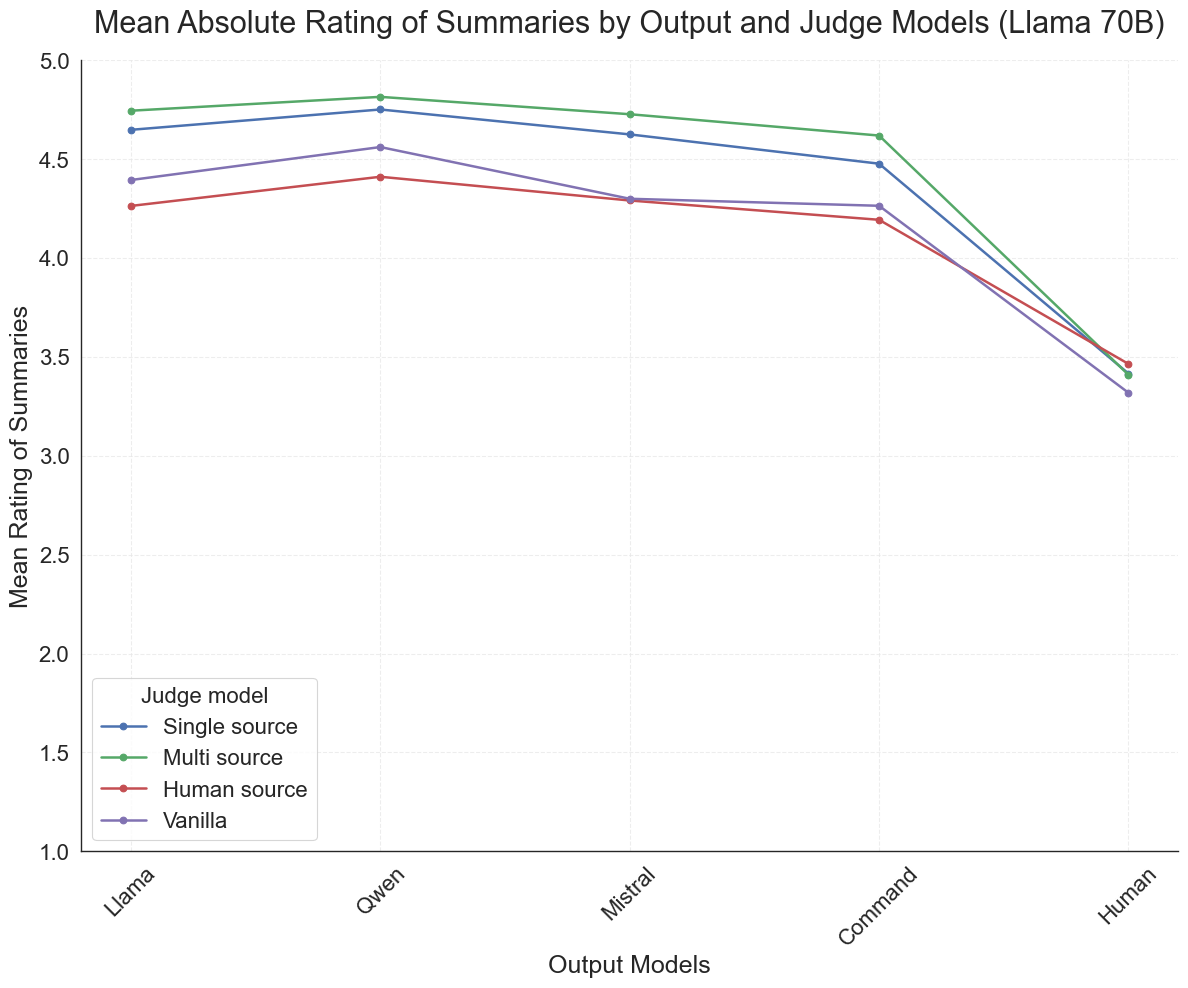

In [48]:
dataset_choice = df_70b_averaged

plt.figure(figsize=(12, 10))
for idx, row in dataset_choice.iterrows():
    plt.plot(dataset_choice.columns, row.values, marker='o', label=idx)

plt.xlabel('Output Models', fontsize=18)
plt.ylabel('Mean Rating of Summaries', fontsize=18)
plt.title('Mean Absolute Rating of Summaries by Output and Judge Models (Llama 70B)', fontsize=22, pad=20)
plt.legend(fontsize=16, title="Judge model", title_fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=range(len(dataset_choice.columns)), labels=[col.capitalize() for col in dataset_choice.columns], rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(1, 5)
plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/llama_70b/line_abs_medium.png')
plt.show()


# Look at summaries

In [59]:
articles = []
summaries = []

with open("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/model_summaries/small/summaries_all.jsonl", "r") as f:
    for line in f:
        data = json.loads(line)
        articles.append(data["article"])
        summaries.append(data["response_model"])

mean_article_length = np.mean([len(article.split()) for article in articles])
mean_summary_length = np.mean([len(summary.split()) for summary in summaries])

print(f"Mean article length: {mean_article_length}")
print("Max article length: ", max([len(article.split()) for article in articles]))
print(f"Mean summary length: {mean_summary_length}")
print("Max summary length: ", max([len(summary.split()) for summary in summaries]))
print(mean_article_length * 2 + mean_summary_length * 2)


Mean article length: 715.15
Max article length:  1512
Mean summary length: 131.488
Max summary length:  386
1693.2759999999998
